In [ ]:
import zipfile
import os
import cv2

zip_path = "/content/archive (2).zip"
extract_path = "extracted_images"

# Extract the ZIP file
with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

# Read all images
images = []

for root, dirs, files in os.walk(extract_path):
    for file in files:
        if file.lower().endswith((".jpg", ".jpeg", ".png", ".bmp")):
            img_path = os.path.join(root, file)
            img = cv2.imread(img_path)

            if img is not None:
                images.append(img)

print("Total images loaded:", len(images))

Total images loaded: 71774


In [ ]:
import os

for root, dirs, files in os.walk(extract_path):
    print(root)
    print("Subfolders:", dirs[:5])
    print("Files:", len(files))
    print("-"*50)

extracted_images
Subfolders: ['images']
Files: 0
--------------------------------------------------
extracted_images/images
Subfolders: ['images', 'validation', 'train']
Files: 0
--------------------------------------------------
extracted_images/images/images
Subfolders: ['validation', 'train']
Files: 0
--------------------------------------------------
extracted_images/images/images/validation
Subfolders: ['surprise', 'angry', 'neutral', 'disgust', 'sad']
Files: 0
--------------------------------------------------
extracted_images/images/images/validation/surprise
Subfolders: []
Files: 797
--------------------------------------------------
extracted_images/images/images/validation/angry
Subfolders: []
Files: 960
--------------------------------------------------
extracted_images/images/images/validation/neutral
Subfolders: []
Files: 1216
--------------------------------------------------
extracted_images/images/images/validation/disgust
Subfolders: []
Files: 111
---------------------

In [ ]:
data = []
labels = []

# Corrected path based on previous extraction and directory structure
train_path = os.path.join(extract_path, "images", "images", "train")

for emotion in os.listdir(train_path):

    emotion_folder = os.path.join(train_path, emotion)

    if os.path.isdir(emotion_folder):

        for image_name in os.listdir(emotion_folder):

            image_path = os.path.join(emotion_folder, image_name)

            img = cv2.imread(image_path)

            if img is not None:

                # Convert to Grayscale
                gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

                # Resize
                gray = cv2.resize(gray, (48,48))

                data.append(gray)
                labels.append(emotion)

In [ ]:
print("Number of images:", len(data))
print("Number of labels:", len(labels))
print("Classes:", set(labels))

Number of images: 28821
Number of labels: 28821
Classes: {'disgust', 'sad', 'surprise', 'fear', 'neutral', 'angry', 'happy'}


In [ ]:
import numpy as np

X = np.array(data)

print(X.shape)

(28821, 48, 48)


In [ ]:
# (samples, height, width, channels) - This line was causing a NameError as it's not valid Python code for variable assignment
X = X.reshape(-1, 48, 48, 1)

print(X.shape)

(28821, 48, 48, 1)


In [ ]:
X = X.astype("float32") / 255.0

In [ ]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

y_encoded = encoder.fit_transform(labels)

print(encoder.classes_)

['angry' 'disgust' 'fear' 'happy' 'neutral' 'sad' 'surprise']


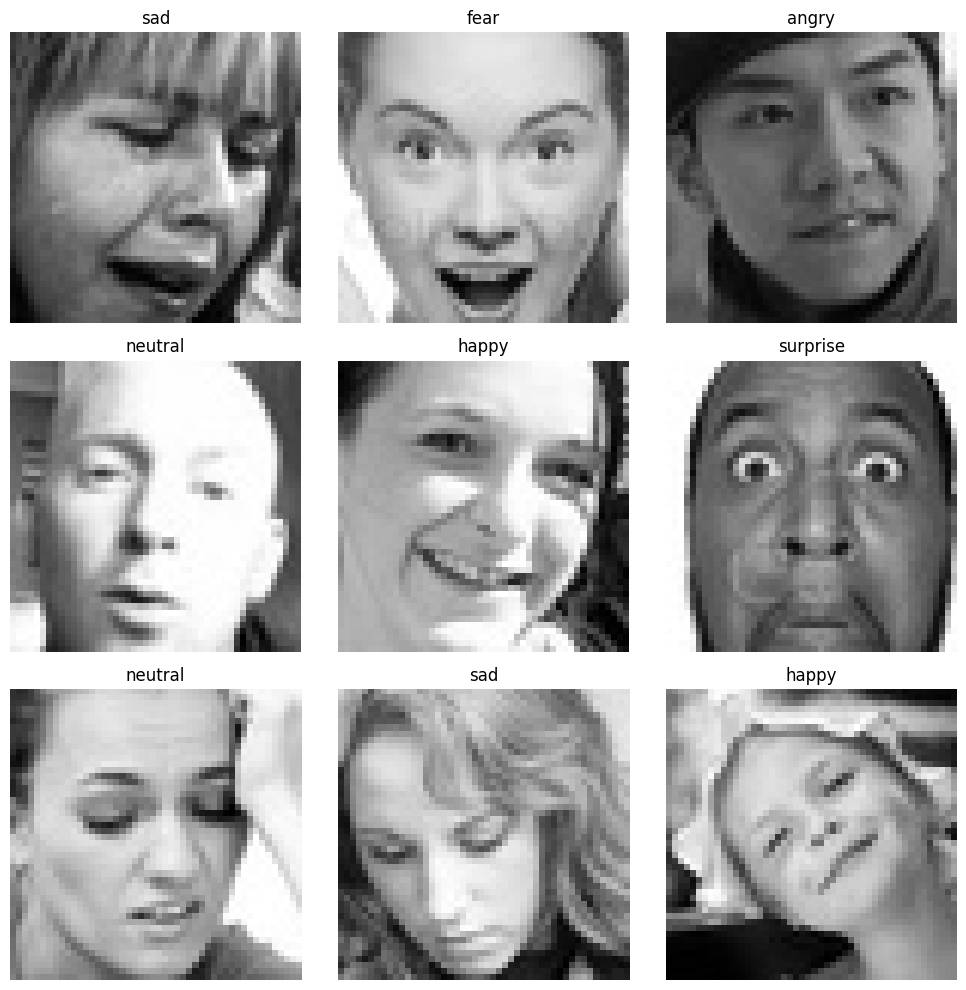

In [ ]:
import matplotlib.pyplot as plt
import random

plt.figure(figsize=(10,10))

for i in range(9):
    idx = random.randint(0, len(data)-1)

    plt.subplot(3,3,i+1)
    plt.imshow(data[idx], cmap='gray')
    plt.title(labels[idx])
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
from tensorflow.keras.utils import to_categorical

num_classes = len(encoder.classes_)

y = to_categorical(y_encoded, num_classes=num_classes)

print(y.shape)

(28821, 7)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(23056, 48, 48, 1)
(5765, 48, 48, 1)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout

model = Sequential()

model.add(
    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(48,48,1)
    )
)

model.add(MaxPooling2D((2,2)))

model.add(
    Conv2D(
        64,
        (3,3),
        activation='relu'
    )
)

model.add(MaxPooling2D((2,2)))

model.add(Flatten())

model.add(Dense(128, activation='relu'))

model.add(Dropout(0.5))

model.add(Dense(num_classes, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=32
)

Epoch 1/10
721/721 ━━━━━━━━━━━━━━━━━━━━ 82s 107ms/step - accuracy: 0.3188 - loss: 1.7129 - val_accuracy: 0.4120 - val_loss: 1.5481
Epoch 2/10
721/721 ━━━━━━━━━━━━━━━━━━━━ 80s 111ms/step - accuracy: 0.4142 - loss: 1.5152 - val_accuracy: 0.4545 - val_loss: 1.4152
Epoch 3/10
721/721 ━━━━━━━━━━━━━━━━━━━━ 74s 102ms/step - accuracy: 0.4497 - loss: 1.4303 - val_accuracy: 0.4699 - val_loss: 1.3861
Epoch 4/10
721/721 ━━━━━━━━━━━━━━━━━━━━ 72s 100ms/step - accuracy: 0.4700 - loss: 1.3770 - val_accuracy: 0.4876 - val_loss: 1.3623
Epoch 5/10
721/721 ━━━━━━━━━━━━━━━━━━━━ 74s 102ms/step - accuracy: 0.4872 - loss: 1.3307 - val_accuracy: 0.4885 - val_loss: 1.3306
Epoch 6/10
721/721 ━━━━━━━━━━━━━━━━━━━━ 81s 101ms/step - accuracy: 0.5022 - loss: 1.2837 - val_accuracy: 0.4968 - val_loss: 1.3136
Epoch 7/10
721/721 ━━━━━━━━━━━━━━━━━━━━ 72s 100ms/step - accuracy: 0.5223 - loss: 1.2409 - val_accuracy: 0.5075 - val_loss: 1.2830
Epoch 8/10
721/721 ━━━━━━━━━━━━━━━━━━━━ 74s 103ms/step - accuracy: 0.5421 - loss: 1

In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

181/181 ━━━━━━━━━━━━━━━━━━━━ 6s 33ms/step - accuracy: 0.5199 - loss: 1.2794
Test Loss: 1.279382586479187
Test Accuracy: 0.5198612213134766


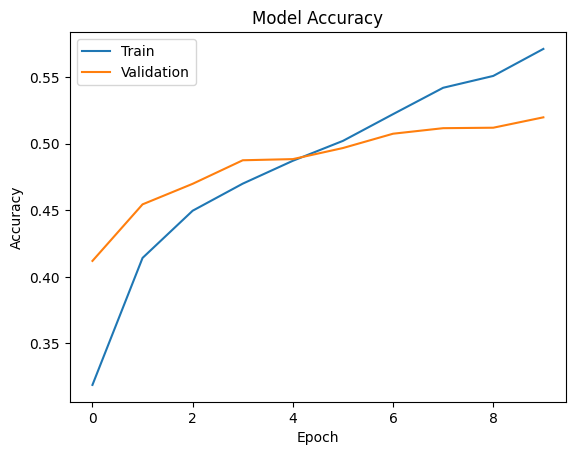

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])

plt.show()

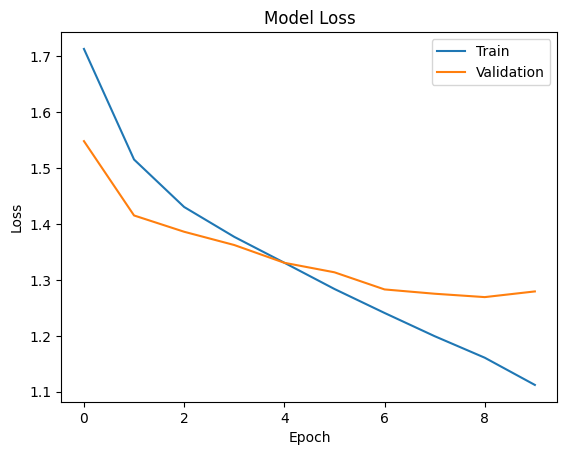

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])

plt.show()

In [ ]:
import numpy as np

predictions = model.predict(X_test)

predicted_class = np.argmax(predictions, axis=1)
true_class = np.argmax(y_test, axis=1)

181/181 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step


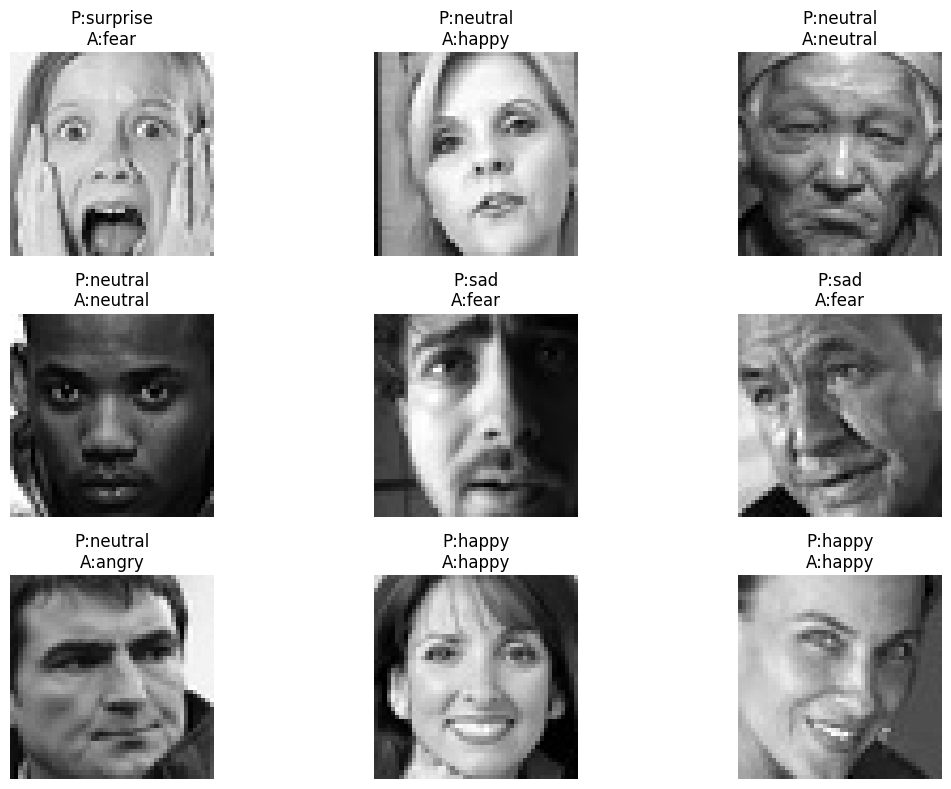

In [ ]:
import matplotlib.pyplot as plt

class_names = encoder.classes_

plt.figure(figsize=(12,8))

for i in range(9):
    plt.subplot(3,3,i+1)

    plt.imshow(X_test[i].reshape(48,48), cmap='gray')

    pred = class_names[predicted_class[i]]
    actual = class_names[true_class[i]]

    plt.title(f"P:{pred}\nA:{actual}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

print(classification_report(
    true_class,
    predicted_class,
    target_names=class_names
))

              precision    recall  f1-score   support

       angry       0.40      0.47      0.44       771
     disgust       1.00      0.01      0.02        95
        fear       0.39      0.20      0.27       827
       happy       0.67      0.78      0.72      1397
     neutral       0.50      0.50      0.50      1045
         sad       0.38      0.42      0.40      1011
    surprise       0.66      0.69      0.68       619

    accuracy                           0.52      5765
   macro avg       0.57      0.44      0.43      5765
weighted avg       0.52      0.52      0.50      5765



In [ ]:
model.save("emotion_cnn_model.h5")

print("Model saved successfully!")

Model saved successfully!


In [ ]:
from tensorflow.keras.models import load_model

# Corrected to load the saved model file, not an image
model = load_model("emotion_cnn_model.h5")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step
Predicted Emotion: sad


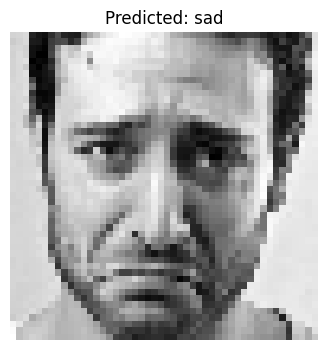

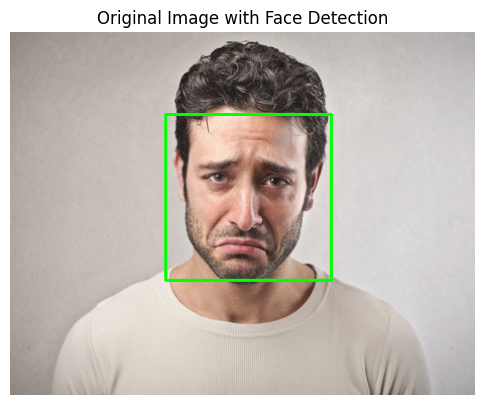

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
)

img = cv2.imread("/content/sad.jpg")

# Convert BGR to RGB for display
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

faces = face_cascade.detectMultiScale(
    gray_img,
    scaleFactor=1.1,
    minNeighbors=5
)

for (x, y, w, h) in faces:

    # Draw rectangle around face
    cv2.rectangle(img_rgb, (x, y), (x+w, y+h), (0, 255, 0), 2)

    face = gray_img[y:y+h, x:x+w]

    face_resized = cv2.resize(face, (48,48))
    face_normalized = face_resized / 255.0
    face_input = face_normalized.reshape(1,48,48,1)

    prediction = model.predict(face_input)

    emotion = encoder.classes_[np.argmax(prediction)]

    print("Predicted Emotion:", emotion)

    # Display detected face
    plt.figure(figsize=(4,4))
    plt.imshow(face_resized, cmap='gray')
    plt.title(f"Predicted: {emotion}")
    plt.axis('off')
    plt.show()

# Display original image with detected face box
plt.figure(figsize=(6,6))
plt.imshow(img_rgb)
plt.title("Original Image with Face Detection")
plt.axis('off')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Predicted Emotion: surprise


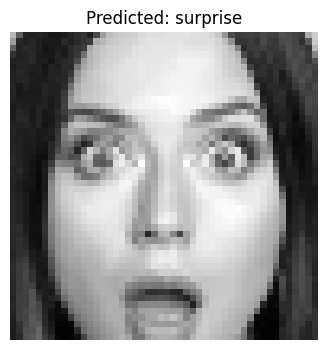

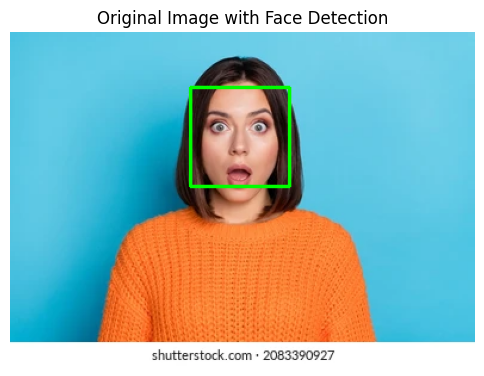

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
)

img = cv2.imread("/content/blah.webp")

# Convert BGR to RGB for display
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

faces = face_cascade.detectMultiScale(
    gray_img,
    scaleFactor=1.1,
    minNeighbors=5
)

for (x, y, w, h) in faces:

    # Draw rectangle around face
    cv2.rectangle(img_rgb, (x, y), (x+w, y+h), (0, 255, 0), 2)

    face = gray_img[y:y+h, x:x+w]

    face_resized = cv2.resize(face, (48,48))
    face_normalized = face_resized / 255.0
    face_input = face_normalized.reshape(1,48,48,1)

    prediction = model.predict(face_input)

    emotion = encoder.classes_[np.argmax(prediction)]

    print("Predicted Emotion:", emotion)

    # Display detected face
    plt.figure(figsize=(4,4))
    plt.imshow(face_resized, cmap='gray')
    plt.title(f"Predicted: {emotion}")
    plt.axis('off')
    plt.show()

# Display original image with detected face box
plt.figure(figsize=(6,6))
plt.imshow(img_rgb)
plt.title("Original Image with Face Detection")
plt.axis('off')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Predicted Emotion: happy


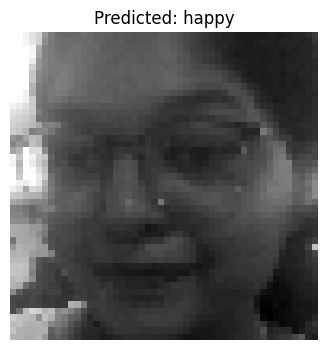

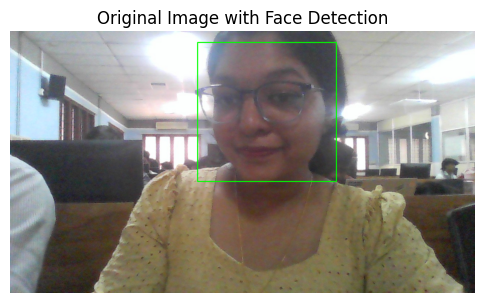

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
)

img = cv2.imread("/content/WIN_20260617_12_18_55_Pro.jpg")

# Convert BGR to RGB for display
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

faces = face_cascade.detectMultiScale(
    gray_img,
    scaleFactor=1.1,
    minNeighbors=5
)

for (x, y, w, h) in faces:

    # Draw rectangle around face
    cv2.rectangle(img_rgb, (x, y), (x+w, y+h), (0, 255, 0), 2)

    face = gray_img[y:y+h, x:x+w]

    face_resized = cv2.resize(face, (48,48))
    face_normalized = face_resized / 255.0
    face_input = face_normalized.reshape(1,48,48,1)

    prediction = model.predict(face_input)

    emotion = encoder.classes_[np.argmax(prediction)]

    print("Predicted Emotion:", emotion)

    # Display detected face
    plt.figure(figsize=(4,4))
    plt.imshow(face_resized, cmap='gray')
    plt.title(f"Predicted: {emotion}")
    plt.axis('off')
    plt.show()

# Display original image with detected face box
plt.figure(figsize=(6,6))
plt.imshow(img_rgb)
plt.title("Original Image with Face Detection")
plt.axis('off')
plt.show()